<div style="text-align:center;padding-top:40px">
<img src="logos/CICESE.jpg" width="180" style="margin-right:20px"/>

# Práctica 1: Modelos Gráficos Probabilistas

## Reconocimiento de Movimientos de Mano con HMM 

---

**Autor:** Javier Ramírez González

**Profesor:** Dr. Irvin Hussein López Nava

Departamento de Ciencias de la Computación

CICESE, Ensenada, B.C.


</div>

## 1. Introducción

El reconocimiento automático de movimientos de la mano es un problema de clasificación de series temporales.
Los **Modelos Ocultos de Markov (HMM)**:

1. Modelan la dinámica temporal mediante estados ocultos.
2. Manejan secuencias de longitud variable.

### 1.1 Datos

| Grupo | Clases | Descripción |
|-------|--------|-------------|
| Contorno (5) | CIRCULO, ARCO, LINEA, SIETE, ZIG | Trayectoria global de la mano |
| Local (3) | CAB, ROTACION-D, ROTACION-O | Movimiento fino de muñeca/antebrazo |

### 1.2 Validación LOOCV

Leave-One-Participant-Out con 5 folds: Train = 4 partic., Test = 1 partic.


## 2. Configuración inicial

In [1]:
import cv2, mediapipe as mp, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pickle, warnings, time, os, sys, copy
from pathlib import Path
from glob import glob
from tqdm.notebook import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import hmmlearn; from hmmlearn import hmm
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode

os.makedirs("resultados", exist_ok=True)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

print(f"  OpenCV {cv2.__version__}, MediaPipe {mp.__version__}")
print(f"  hmmlearn {hmmlearn.__version__}, scikit-learn 1.7.2")
print(f"  NumPy {np.__version__}, Pandas {pd.__version__}")


2026-06-27 22:27:01.462858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-27 22:27:01.475705: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-27 22:27:01.479450: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-27 22:27:01.490221: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-06-27 22:27:02.189829: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

  OpenCV 4.13.0, MediaPipe 0.10.35
  hmmlearn 0.3.3, scikit-learn 1.7.2
  NumPy 1.26.4, Pandas 2.2.3


## 3. Carga y exploración de datos

In [2]:
DATA_DIR = Path("Data")
PARTICIPANTES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
CLASES_CONTORNO = ['CIRCULO', 'ARCO', 'LINEA', 'SIETE', 'ZIG']
CLASES_LOCAL    = ['CAB', 'ROTACION-D', 'ROTACION-O']

archivos = []
for p in PARTICIPANTES:
    archivos.extend(glob(str(DATA_DIR / p / "*.MOV")))
print(f"Total archivos: {len(archivos)}")
print(f"Participantes: {PARTICIPANTES}")

def parsear(ruta):
    n = Path(ruta).stem
    parts = n.split('_')
    return {
        'archivo': ruta,
        'participante': parts[0],
        'clase': parts[1],
        'version': parts[2],
        'inverso': 'Inverso' in n,
        'grupo': 'contorno' if parts[1] in CLASES_CONTORNO else 'local'
    }

df = pd.DataFrame([parsear(a) for a in archivos])
print(f"Shape: {df.shape}")
print(df.head())


Total archivos: 490
Participantes: ['P00', 'P01', 'P02', 'P03', 'P04']
Shape: (490, 6)
                                        archivo participante  clase version  \
0                Data/P00/P00_CAB_V1_Frente.MOV          P00    CAB      V1   
1      Data/P00/P00_ARCO_V1_Horizontal-Mini.MOV          P00   ARCO      V1   
2       Data/P00/P00_ZIG_V1_Horizontal-Mini.MOV          P00    ZIG      V1   
3  Data/P00/P00_SIETE_V1_Horizontal-Mediano.MOV          P00  SIETE      V1   
4      Data/P00/P00_ZIG_V1_Vertical-Mediano.MOV          P00    ZIG      V1   

   inverso     grupo  
0    False     local  
1    False  contorno  
2    False  contorno  
3    False  contorno  
4    False  contorno  


In [3]:
# Guardar el DataFrame en un archivo CSV
df.to_csv("resultados/dataset_info.csv", index=False)
print(f" CSV guardado en: resultados/dataset_info.csv")

# También puedes guardarlo con ruta completa usando Path
from pathlib import Path
ruta_csv = Path("resultados/dataset_info.csv")
df.to_csv(ruta_csv, index=False)
print(f" CSV guardado en: {ruta_csv.absolute()}")

 CSV guardado en: resultados/dataset_info.csv
 CSV guardado en: /home/jabonsote/Desktop/PATRONES/Mov/resultados/dataset_info.csv


In [4]:
print("=== Distribución por clase ===")
print(df['clase'].value_counts().to_string())
print("\n=== Por participante ===")
print(df['participante'].value_counts().sort_index().to_string())
print(f"\nContorno: {df[df['grupo']=='contorno'].shape[0]} muestras")
print(f"Local:     {df[df['grupo']=='local'].shape[0]} muestras")


=== Distribución por clase ===
clase
ARCO          160
CIRCULO        60
CAB            50
ROTACION-D     50
ROTACION-O     50
ZIG            40
SIETE          40
LINEA          40

=== Por participante ===
participante
P00    98
P01    98
P02    98
P03    98
P04    98

Contorno: 340 muestras
Local:     150 muestras


### 3.1 Visualización de distribución

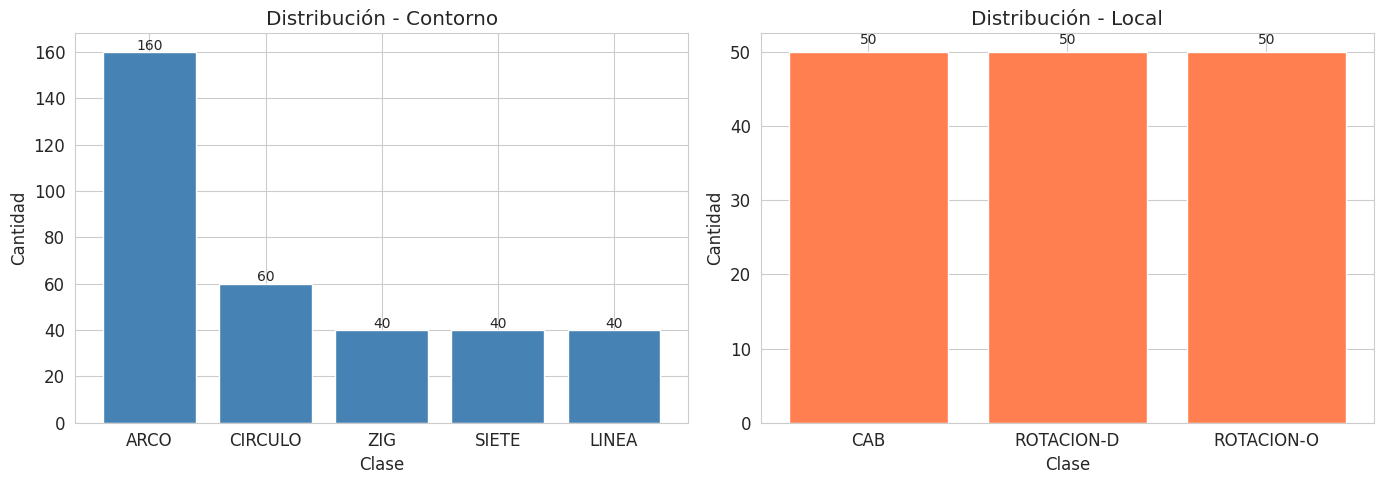

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grupo, color in zip(axes, ['contorno', 'local'], ['steelblue', 'coral']):
    tmp = df[df['grupo']==grupo]['clase'].value_counts()
    bars = ax.bar(tmp.index, tmp.values, color=color, edgecolor='white')
    ax.set_title(f'Distribución - {grupo.capitalize()}')
    ax.set_xlabel('Clase'); ax.set_ylabel('Cantidad')
    for i, v in enumerate(tmp.values):
        ax.text(i, v+1, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('resultados/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Extracción de características

Solo landmarks crudos (63D).

In [6]:
model_path = "hand_landmarker.task"
base_opt = BaseOptions(model_asset_path=model_path)
opts = vision.HandLandmarkerOptions(
    base_options=base_opt,
    running_mode=VisionTaskRunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
hand_landmarker = vision.HandLandmarker.create_from_options(opts)
print("HandLandmarker listo")


HandLandmarker listo


I0000 00:00:1782624424.222557   93336 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782624424.361409   93350 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.195.03), renderer: NVIDIA GeForce RTX 3060/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782624424.384203   93339 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782624424.395922   93339 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [7]:
CACHE = Path("resultados/features_cache.pkl")
global_ts = 0

def extraer_landmarks(ruta):
    """Extrae landmarks + características de ingeniería."""
    global global_ts
    cap = cv2.VideoCapture(str(ruta))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    raw_landmarks = []
    wrist_traj = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = hand_landmarker.detect_for_video(img, int(global_ts))
        global_ts += 1000.0 / fps
        if result.hand_landmarks:
            hand = result.hand_landmarks[0]
            w = hand[0]
            wrist_traj.append([w.x, w.y, w.z])
            # Landmarks normalizados a muñeca
            pts = np.array([[lm.x - w.x, lm.y - w.y, lm.z - w.z] for lm in hand])
            raw_landmarks.append(pts)
    cap.release()
    if len(raw_landmarks) < 5:
        return None
    arr = np.array(raw_landmarks)  # (T, 21, 3)
    wrist = np.array(wrist_traj)   # (T, 3)

    # === Posición + Velocidad + Muñeca (129D) ===
    pos = arr.reshape(arr.shape[0], -1)  # (T, 63)
    vel = np.diff(pos, n=1, axis=0, prepend=pos[:1])
    features = np.hstack([pos, vel, wrist])  # (T, 129)
    return features.astype(np.float32)

def extraer_todas(archivos_list, forzar=False):
    if CACHE.exists() and not forzar:
        with open(CACHE, "rb") as f:
            return pickle.load(f)
    out = {}
    for r in tqdm(archivos_list, desc="Procesando"):
        try:
            feats = extraer_landmarks(r)
            if feats is not None:
                out[r] = feats
        except Exception as e:
            print(f"  Error en {Path(r).name}: {e}")
    with open(CACHE, "wb") as f:
        pickle.dump(out, f)
    return out

t0 = time.time()
features_dict = extraer_todas(archivos, forzar=False)
t1 = time.time()
longitudes = [len(v) for v in features_dict.values()]
print(f"Videos procesados: {len(features_dict)}/{len(archivos)}")
print(f"Sin detección: {len(archivos)-len(features_dict)}")
print(f"Tiempo: {t1-t0:.1f}s")
print(f"Largo: min={min(longitudes)}, max={max(longitudes)}, media={np.mean(longitudes):.1f}")
print(f"Dimensiones por frame: {list(features_dict.values())[0].shape[1]}")


Videos procesados: 490/490
Sin detección: 0
Tiempo: 0.2s
Largo: min=9, max=99, media=34.0
Dimensiones por frame: 129


## 5. Data Augmentation para clases minoritarias

- Ruido gaussiano pequeño en landmarks (σ=0.005)
- Scaling isotrópico leve (0.95-1.05)
- Warping temporal (ligero estiramiento/compresión)
- Cada clase minoritaria (40 muestras) se aumenta a ~60 muestras


In [8]:
def augment_sequence(seq, factor=3, rng=None):
    """Genera 'factor' secuencias aumentadas por cada original."""
    T, D = seq.shape
    if rng is None:
        rng = np.random.default_rng(42)
    augmented = []
    for _ in range(factor):
        aug = seq.copy()
        noise = rng.normal(0, 0.005, aug.shape)
        aug = aug + noise
        scale = rng.uniform(0.95, 1.05)
        aug[:, :63] *= scale
        if T > 10:
            new_len = int(T * rng.uniform(0.9, 1.1))
            x_old = np.linspace(0, 1, T)
            x_new = np.linspace(0, 1, new_len)
            aug = np.array([np.interp(x_new, x_old, aug[:, d]) for d in range(D)]).T
        augmented.append(aug)
    return augmented

def augment_minorities(X, y, min_count=60, factor=2):
    """Aumenta clases minoritarias hasta min_count muestras."""
    from collections import Counter
    rng = np.random.default_rng(42)
    counts = Counter(y)
    X_new, y_new = list(X), list(y)
    for cls, cnt in counts.items():
        if cnt >= min_count:
            continue
        needed = min_count - cnt
        indices = [i for i, c in enumerate(y) if c == cls]
        rng.shuffle(indices)
        augmented_count = 0
        for idx in indices:
            if augmented_count >= needed:
                break
            augs = augment_sequence(X[idx], factor=factor, rng=rng)
            for a in augs:
                if augmented_count >= needed:
                    break
                X_new.append(a)
                y_new.append(cls)
                augmented_count += 1
    return X_new, y_new


## 6. Preprocesamiento

**Normalización:**
- **Contorno:** z-score por secuencia (preserva patrones temporales)
- **Local:** z-score por fold (media/std de todos los train)
**PCA:** Solo para Local (95% varianza). Para Contorno se omitió porque la PCA
eliminaba información discriminativa (solo 3-5 componentes retenidas).


In [9]:
def preparar_datos(grupo, clases, df, feats):
    mask = (df["grupo"] == grupo) & (df["archivo"].isin(feats))
    rows = df[mask]
    X, y, g = [], [], []
    for _, r in rows.iterrows():
        X.append(feats[r["archivo"]])
        y.append(r["clase"])
        g.append(r["participante"])
    return X, y, g, rows

X_c, y_c, g_c, df_c = preparar_datos("contorno", CLASES_CONTORNO, df, features_dict)
X_l, y_l, g_l, df_l = preparar_datos("local", CLASES_LOCAL, df, features_dict)

print(f"Contorno: {len(X_c)} muestras, {len(set(y_c))} clases")
print(f"  Clases: {pd.Series(y_c).value_counts().to_dict()}")
print(f"Local:    {len(X_l)} muestras, {len(set(y_l))} clases")
print(f"  Clases: {pd.Series(y_l).value_counts().to_dict()}")

D_BASE = X_c[0].shape[1]
print(f"\nDimensiones originales: {D_BASE}")


Contorno: 340 muestras, 5 clases
  Clases: {'ARCO': 160, 'CIRCULO': 60, 'ZIG': 40, 'SIETE': 40, 'LINEA': 40}
Local:    150 muestras, 3 clases
  Clases: {'CAB': 50, 'ROTACION-D': 50, 'ROTACION-O': 50}

Dimensiones originales: 129



████████████████████████████████████████████████████████████
  ANÁLISIS DE BALANCEO DE CLASES
████████████████████████████████████████████████████████████

  CONTORNO (target=60 por clase)
Clase           Actual   Target   Diferencia  
-------------------------------------------
ARCO            160      60       sobran 100
CIRCULO         60       60       OK
LINEA           40       60       faltan 20
SIETE           40       60       faltan 20
ZIG             40       60       faltan 20

Total a generar por augmentation: 60
Total a eliminar por undersampling: 100

  LOCAL (target=50 por clase)
Clase           Actual   Target   Diferencia  
-------------------------------------------
CAB             50       50       OK
ROTACION-D      50       50       OK
ROTACION-O      50       50       OK

Total a generar por augmentation: 0
Total a eliminar por undersampling: 0

  Estrategia intra-fold en LOOCV:
  1. Augment: LINEA, SIETE, ZIG (40 -> 60); CIRCULO (60) se deja igual
  2. Undersam

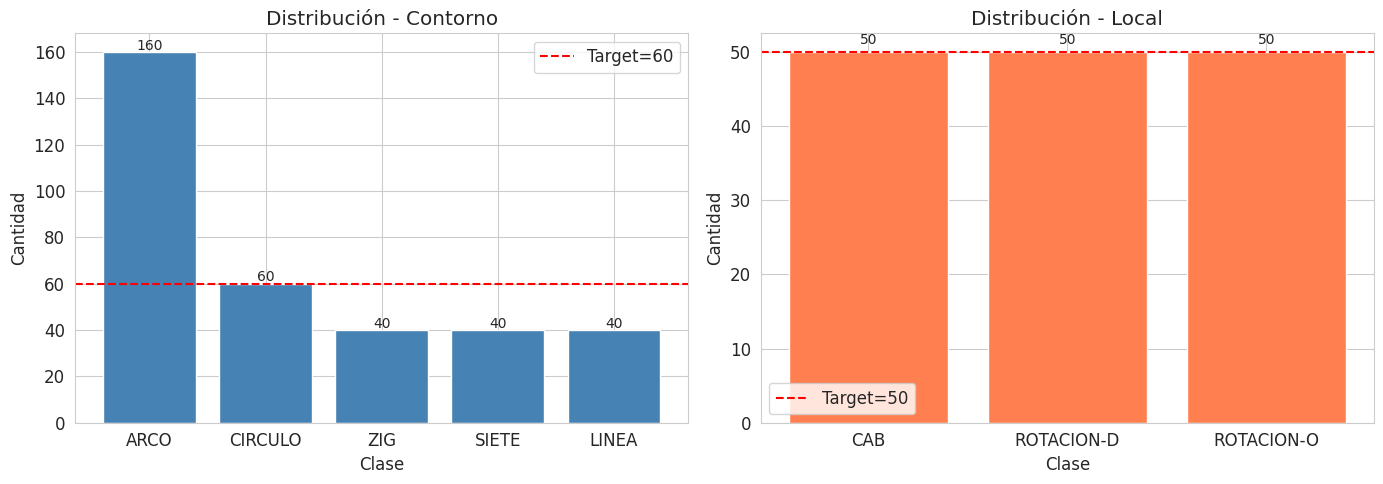

In [10]:
# === Análisis de balanceo de clases antes del entrenamiento ===
# Objetivo: Contorno -> 60 muestras/clase, Local -> 50 muestras/clase
from collections import Counter

def analizar_balanceo(X, y, grupo, target):
    cnt = Counter(y)
    print(f"\n{'='*50}")
    print(f"  {grupo.upper()} (target={target} por clase)")
    print(f"{'='*50}")
    print(f"{'Clase':<15} {'Actual':<8} {'Target':<8} {'Diferencia':<12}")
    print('-'*43)
    faltantes = 0
    for cls in sorted(cnt.keys()):
        diff = target - cnt[cls]
        faltantes += max(0, diff)
        if diff > 0:
            edo = f'faltan {diff}'
        elif diff < 0:
            edo = f'sobran {-diff}'
        else:
            edo = 'OK'
        print(f'{cls:<15} {cnt[cls]:<8} {target:<8} {edo}')
    print(f'\nTotal a generar por augmentation: {faltantes}')
    print(f'Total a eliminar por undersampling: {sum(max(0, cnt[c]-target) for c in cnt)}')
    return cnt

print("\n" + "█"*60)
print("  ANÁLISIS DE BALANCEO DE CLASES")
print("█"*60)
cnt_c = analizar_balanceo(X_c, y_c, 'Contorno', target=60)
cnt_l = analizar_balanceo(X_l, y_l, 'Local', target=50)

# Verificación rápida: ¿están balanceadas? (se hace intra-fold en LOOCV)
print(f"\n{'='*60}")
print("  Estrategia intra-fold en LOOCV:")
print("  1. Augment: LINEA, SIETE, ZIG (40 -> 60); CIRCULO (60) se deja igual")
print("  2. Undersample: ARCO (160 -> 60)")
print("  3. Local: CAB, ROTACION-D, ROTACION-O ya están en 50 -> sin cambios")
print(f"{'='*60}\n")

# Guardar figura de distribución con target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grupo, color, target in zip(
    axes, ['contorno', 'local'], ['steelblue', 'coral'], [60, 50]):
    tmp = df[df['grupo']==grupo]['clase'].value_counts()
    bars = ax.bar(tmp.index, tmp.values, color=color, edgecolor='white')
    ax.axhline(y=target, color='red', linestyle='--', linewidth=1.5,
               label=f'Target={target}')
    ax.set_title(f'Distribución - {grupo.capitalize()}')
    ax.set_xlabel('Clase'); ax.set_ylabel('Cantidad')
    for i, v in enumerate(tmp.values):
        ax.text(i, v+1, str(v), ha='center', fontsize=10)
    ax.legend()
plt.tight_layout()
plt.savefig('resultados/distribucion_balance_target.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Modelo Oculto de Markov 

Un HMM se define como λ = (π, A, B):
- **π**: distribución inicial sobre estados ocultos
- **A**: matriz de transición entre estados
- **B**: emisiones Gaussianas (observaciones)

Se entrena **1 HMM por clase** y la clasificación usa máxima verosimilitud.


### Arquitectura

Mitra y Acharya (2007) identifican los HMM left-to-right como los más adecuados para gestos dinámicos,
con estados que transicionan solo hacia adelante en el tiempo ($a_{ij}=0$ si $j<i$).
Cada clase se modela con un HMM independiente ($\lambda_1, \ldots, \lambda_M$) y la clasificación
asigna la clase de mayor log-verosimilitud. La Figura 1 muestra la arquitectura empleada.



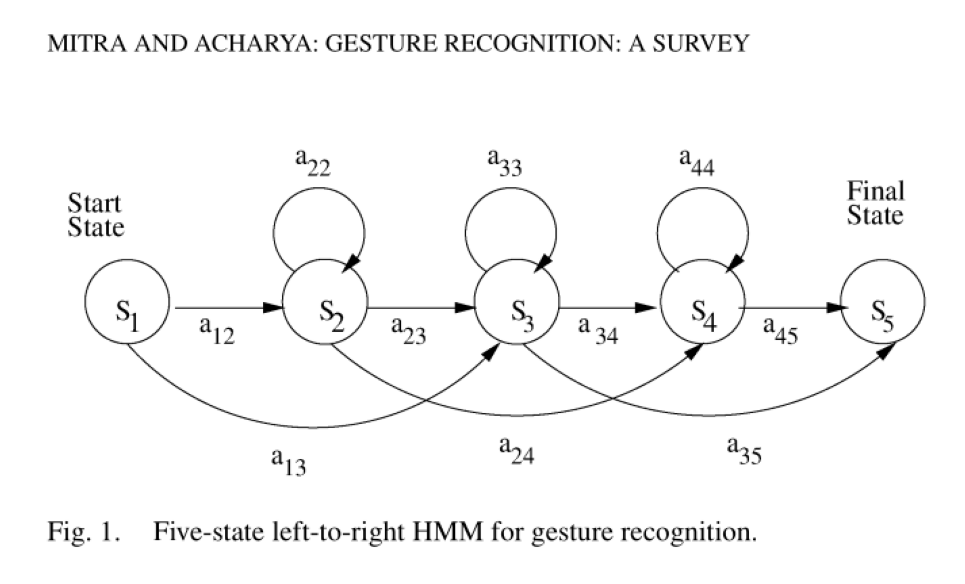

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('HMM.png')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### 7.1 Grid Search de hiperparámetros

Se busca el número óptimo de estados ocultos usando validación cruzada Estratificada
dentro del conjunto de entrenamiento de cada fold.


In [12]:
def grid_search_hmm(X_tr, y_tr, n_states_list=[3,4,5,6,7], n_inits=3, n_jobs=-1):
    """Grid search por accuracy con paralelización (joblib).
    
    Para cada clase, prueba cada N entrenando un HMM y clasificando
    un fold de validación interna. Selecciona N que maximiza accuracy.
    """
    from sklearn.model_selection import StratifiedKFold
    from joblib import Parallel, delayed
    from collections import defaultdict
    import warnings
    warnings.filterwarnings('ignore')
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    classes = sorted(set(y_tr))
    
    # Agrupar secuencias por clase
    seqs_by_class = {}
    for i, (seq, label) in enumerate(zip(X_tr, y_tr)):
        seqs_by_class.setdefault(label, []).append(seq)
    
    def _entrenar_hmm_clase(seqs, n):
        """Entrena un HMM para una clase con N estados."""
        mdl = hmm.GaussianHMM(n_components=n, covariance_type='diag',
                              n_iter=500, tol=1e-3, random_state=42,
                              init_params='kmeans', params='mcst')
        Xc = np.vstack(seqs)
        lengths = [len(s) for s in seqs]
        with open(os.devnull, 'w') as dn:
            old_out, old_err = sys.stdout, sys.stderr
            sys.stdout, sys.stderr = dn, dn
            try:
                mdl.fit(Xc, lengths)
            finally:
                sys.stdout, sys.stderr = old_out, old_err
        return mdl
    
    def _evaluar_clase_n(cls, n):
        """Evalúa un HMM para una clase con N estados usando CV interna."""
        fold_accs = []
        seqs = seqs_by_class[cls]
        other_seqs = []
        for c, s in seqs_by_class.items():
            if c != cls:
                other_seqs.extend(s)
        
        for train_idx, val_idx in skf.split(seqs, [0]*len(seqs)):
            train_cls = [seqs[i] for i in train_idx]
            val_cls = [seqs[i] for i in val_idx]
            
            if not train_cls or not val_cls:
                continue
            
            try:
                mdl = _entrenar_hmm_clase(train_cls, n)
                
                # Clasificar: esta clase vs otras
                correct = 0
                total = 0
                
                for seq in val_cls:
                    try:
                        ll = mdl.score(seq)
                        if ll > -1e10:
                            correct += 1
                    except:
                        pass
                    total += 1
                
                for other_seq in other_seqs[:len(val_cls)]:
                    try:
                        ll = mdl.score(other_seq)
                        if ll < -1e10:
                            correct += 1
                    except:
                        pass
                    total += 1
                
                fold_accs.append(correct / total if total > 0 else 0.0)
            except:
                pass
        
        return (cls, n, np.mean(fold_accs) if fold_accs else 0.0)
    
    # Generar todas las tareas
    tasks = [(cls, n) for cls in classes for n in n_states_list]
    print(f"  Total tareas: {len(tasks)} ({len(classes)} clases × {len(n_states_list)} N)")
    print(f"  Paralelizando con {n_jobs} workers...")
    
    # Ejecutar en paralelo
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(_evaluar_clase_n)(cls, n) for cls, n in tasks
    )
    
    # Seleccionar mejor N por clase
    scores = defaultdict(dict)
    for cls, n, acc in results:
        scores[cls][n] = acc
    
    best_states = {}
    for cls in classes:
        best_n = max(scores[cls], key=scores[cls].get)
        best_states[cls] = best_n
        print(f"  {cls}: N={best_n} (acc={scores[cls][best_n]:.3f})")
    
    return best_states


In [13]:
print("=== Grid Search por accuracy ===")
print("\n--- Contorno ---")
n_opt_c = grid_search_hmm(X_c, y_c, n_states_list=[3,4,5,6,7], n_inits=3, n_jobs=-1)
for cls, n in n_opt_c.items():
    print(f"  {cls}: {n} estados")
print()
print("\n--- Local ---")
n_opt_l = grid_search_hmm(X_l, y_l, n_states_list=[3,4,5,6,7], n_inits=3, n_jobs=-1)
for cls, n in n_opt_l.items():
    print(f"  {cls}: {n} estados")


=== Grid Search por accuracy ===

--- Contorno ---
  Total tareas: 25 (5 clases × 5 N)
  Paralelizando con -1 workers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:   35.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


  ARCO: N=3 (acc=0.500)
  CIRCULO: N=3 (acc=0.500)
  LINEA: N=3 (acc=0.500)
  SIETE: N=3 (acc=0.500)
  ZIG: N=3 (acc=0.500)
  ARCO: 3 estados
  CIRCULO: 3 estados
  LINEA: 3 estados
  SIETE: 3 estados
  ZIG: 3 estados


--- Local ---
  Total tareas: 15 (3 clases × 5 N)
  Paralelizando con -1 workers...


[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    1.0s remaining:    0.9s


  CAB: N=3 (acc=0.500)
  ROTACION-D: N=3 (acc=0.500)
  ROTACION-O: N=3 (acc=0.500)
  CAB: 3 estados
  ROTACION-D: 3 estados
  ROTACION-O: 3 estados


[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:   12.0s finished


## 8. Entrenamiento y evaluación LOOCV

Se usa el número óptimo de estados por clase (grid search de la sección 7.1).

**Proceso intra-fold:**
1. Separar train/test por participante
2. Normalización por secuencia (z-score)
3. Data augmentation en clases minoritarias de train
4. Under-sampling de clase mayoritaria
5. Entrenar HMM por clase con estados óptimos
6. Clasificar test con máxima verosimilitud


In [14]:
# ============================================================
# 8. Entrenamiento y evaluación LOOCV (paralelo)
# ============================================================

# Estados óptimos (ya definidos en celda 22 por grid search)
assert 'n_opt_c' in dir() and 'n_opt_l' in dir(), \
    "Ejecuta primero la celda del grid search (sección 7.1)"
print("Estados óptimos del grid search:")
print(f"  Contorno: {n_opt_c}")
print(f"  Local:    {n_opt_l}")

from joblib import Parallel, delayed

def _entrenar_un_hmm(args):
    """Entrena un HMM para una clase (unidad paralelizable)."""
    seqs, n, n_inits, seed = args
    Xc = np.vstack(seqs)
    lengths = [len(s) for s in seqs]
    best_ll = -np.inf
    best_mdl = None
    for init in range(n_inits):
        try:
            mdl = hmm.GaussianHMM(n_components=n, covariance_type='diag',
                                  n_iter=1000, tol=1e-4, random_state=seed+init,
                                  init_params='kmeans', params='mcst')
            with open(os.devnull, 'w') as dn:
                old_out, old_err = sys.stdout, sys.stderr
                sys.stdout, sys.stderr = dn, dn
                try:
                    mdl.fit(Xc, lengths)
                finally:
                    sys.stdout, sys.stderr = old_out, old_err
            ll = mdl.score(Xc)
            if ll > best_ll:
                best_ll = ll
                best_mdl = mdl
        except:
            pass
    return best_mdl

def entrenar_hmm(X_tr, y_tr, n_states_dict=None, n_inits=5, default_n=4, n_jobs=-1):
    """Entrena HMM por clase EN PARALELO con múltiples inicializaciones."""
    clases = sorted(set(y_tr))
    tasks = []
    task_classes = []
    for c in clases:
        n = n_states_dict.get(c, default_n) if n_states_dict else default_n
        seqs = [X_tr[i] for i, lbl in enumerate(y_tr) if lbl == c]
        if not seqs or sum(len(s) for s in seqs) < n:
            continue
        tasks.append((seqs, n, n_inits, 42))
        task_classes.append(c)
    
    modelos_list = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(_entrenar_un_hmm)(t) for t in tasks
    )
    
    modelos = {}
    for c, mdl in zip(task_classes, modelos_list):
        if mdl is not None:
            modelos[c] = mdl
    return modelos

def clasificar(modelos, X_te, y_tr):
    preds = []
    fallback = max(set(y_tr), key=y_tr.count) if y_tr else None
    for seq in X_te:
        best_ll, best_c = -np.inf, fallback
        for c, mdl in modelos.items():
            try:
                ll = mdl.score(seq)
                if ll > best_ll:
                    best_ll, best_c = ll, c
            except:
                pass
        preds.append(best_c)
    return preds

def _evaluar_fold(args):
    """Evalúa un fold del LOOCV (unidad paralelizable)."""
    (X_tr_raw, y_tr, X_te_raw, y_te, part_test,
     use_pca, augment, undersample_majority, per_sequence_norm,
     n_states_dict, default_n, n_inits) = args
    
    # 1. Normalización por secuencia (z-score)
    X_tr_norm = []
    for s in X_tr_raw:
        mu = s.mean(axis=0)
        std = s.std(axis=0)
        std[std < 1e-8] = 1.0
        X_tr_norm.append((s - mu) / std)
    X_te_norm = []
    for s in X_te_raw:
        mu = s.mean(axis=0)
        std = s.std(axis=0)
        std[std < 1e-8] = 1.0
        X_te_norm.append((s - mu) / std)
    
    # 2. PCA intra-fold
    n_comp = None
    if use_pca:
        X_tr_concat = np.vstack(X_tr_norm)
        pca = PCA(n_components=min(0.95, 0.95), svd_solver='full')
        pca.fit(X_tr_concat)
        cumsum = np.cumsum(pca.explained_variance_ratio_)
        n_comp = np.searchsorted(cumsum, 0.95) + 1
        pca = PCA(n_components=n_comp, svd_solver='full')
        pca.fit(X_tr_concat)
        X_tr_pca = [pca.transform(s) for s in X_tr_norm]
        X_te_pca = [pca.transform(s) for s in X_te_norm]
    else:
        X_tr_pca = X_tr_norm
        X_te_pca = X_te_norm
    
    # 3. Data augmentation
    if augment:
        X_tr_aug, y_tr_aug = augment_minorities(X_tr_pca, y_tr, min_count=60, factor=2)
    else:
        X_tr_aug, y_tr_aug = X_tr_pca, y_tr
    
    # 4. Under-sampling
    if undersample_majority:
        from collections import Counter
        rng_us = np.random.default_rng(42)
        cnt = Counter(y_tr_aug)
        max_allowed = int(np.median(list(cnt.values())))
        X_bal, y_bal = [], []
        for cls, n in cnt.items():
            indices = [i for i, c in enumerate(y_tr_aug) if c == cls]
            if n > max_allowed:
                indices = rng_us.choice(indices, size=max_allowed, replace=False).tolist()
            for i in indices:
                X_bal.append(X_tr_aug[i])
                y_bal.append(cls)
        X_tr_bal, y_tr_bal = X_bal, y_bal
    else:
        X_tr_bal, y_tr_bal = X_tr_aug, y_tr_aug
    
    # 5. Entrenar HMM por clase (paralelo)
    modelos = entrenar_hmm(X_tr_bal, y_tr_bal,
                           n_states_dict=n_states_dict,
                           default_n=default_n, n_inits=n_inits, n_jobs=-1)
    
    # 6. Clasificar
    preds = clasificar(modelos, X_te_pca, y_tr)
    acc = accuracy_score(y_te, preds)
    
    pca_info = f' [PCA={n_comp}]' if use_pca else ''
    return (part_test, acc, len(y_te), pca_info, y_te, preds)

def evaluar_loocv(X, y, groups, nombre, default_n=4, use_pca=True,
                  augment=True, undersample_majority=False,
                  per_sequence_norm=False, n_states_dict=None, n_inits=5):
    """LOOCV con folds en paralelo."""
    logo = LeaveOneGroupOut()
    yt, yp = [], []
    print(f"\n{'='*60}\n{nombre}\n{'='*60}")
    
    # Preparar folds
    fold_args = []
    for train_idx, test_idx in logo.split(X, y, groups=groups):
        part_test = groups[test_idx[0]]
        args = (
            [X[i] for i in train_idx],
            [y[i] for i in train_idx],
            [X[i] for i in test_idx],
            [y[i] for i in test_idx],
            part_test,
            use_pca, augment, undersample_majority, per_sequence_norm,
            n_states_dict, default_n, n_inits
        )
        fold_args.append(args)
    
    # Ejecutar folds en paralelo
    results = Parallel(n_jobs=-1, verbose=1)(
        delayed(_evaluar_fold)(args) for args in fold_args
    )
    
    # Recoger resultados
    for part_test, acc, n_samples, pca_info, y_true, y_pred in results:
        print(f"  {part_test}: acc={acc:.3f} ({n_samples} muestras){pca_info}")
        yt.extend(y_true)
        yp.extend(y_pred)
    
    acc_g = accuracy_score(yt, yp)
    print(f"  -> Accuracy global: {acc_g:.3f}")
    return yt, yp


Estados óptimos del grid search:
  Contorno: {'ARCO': 3, 'CIRCULO': 3, 'LINEA': 3, 'SIETE': 3, 'ZIG': 3}
  Local:    {'CAB': 3, 'ROTACION-D': 3, 'ROTACION-O': 3}


### 8.1 Evaluación de Contorno


In [15]:
yt_c, yp_c = evaluar_loocv(
    X_c, y_c, g_c, "CONTORNO (5 clases)",
    default_n=5, use_pca=False, augment=True,
    per_sequence_norm=True, undersample_majority=True,
    n_states_dict=n_opt_c
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



CONTORNO (5 clases)


Model is not converging.  Current: -299925.3554732911 is not greater than -299925.3533649906. Delta is -0.002108300512190908
Model is not converging.  Current: -467962.6252251053 is not greater than -467962.6227103156. Delta is -0.002514789695851505


  P00: acc=0.368 (68 muestras)
  P01: acc=0.309 (68 muestras)
  P02: acc=0.235 (68 muestras)
  P03: acc=0.368 (68 muestras)
  P04: acc=0.426 (68 muestras)
  -> Accuracy global: 0.341


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   32.3s finished


### 8.2 Evaluación de Local


In [16]:
yt_l, yp_l = evaluar_loocv(
    X_l, y_l, g_l, "LOCAL (3 clases)",
    default_n=5, use_pca=True, augment=True,
    n_states_dict=n_opt_l
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



LOCAL (3 clases)
  P00: acc=0.800 (30 muestras) [PCA=29]
  P01: acc=0.833 (30 muestras) [PCA=28]
  P02: acc=0.867 (30 muestras) [PCA=28]
  P03: acc=0.300 (30 muestras) [PCA=29]
  P04: acc=0.667 (30 muestras) [PCA=29]
  -> Accuracy global: 0.693


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   18.1s finished


## 9. Resultados

In [17]:
def reporte_completo(yt, yp, clases, nombre):
    print(f"\n{'='*60}\n{nombre}\n{'='*60}")
    print(classification_report(yt, yp, labels=clases, digits=3))
    cm = confusion_matrix(yt, yp, labels=clases)
    df_cm = pd.DataFrame(cm, index=clases, columns=clases)
    df_cm.index.name = 'Real'; df_cm.columns.name = 'Predicho'
    return cm, df_cm

cm_c, df_cm_c = reporte_completo(yt_c, yp_c, CLASES_CONTORNO, "CONTORNO")
cm_l, df_cm_l = reporte_completo(yt_l, yp_l, CLASES_LOCAL, "LOCAL")



CONTORNO
              precision    recall  f1-score   support

     CIRCULO      0.203     0.400     0.270        60
        ARCO      0.684     0.338     0.452       160
       LINEA      0.407     0.600     0.485        40
       SIETE      0.233     0.250     0.241        40
         ZIG      0.098     0.100     0.099        40

    accuracy                          0.341       340
   macro avg      0.325     0.338     0.309       340
weighted avg      0.444     0.341     0.357       340


LOCAL
              precision    recall  f1-score   support

         CAB      0.552     0.740     0.632        50
  ROTACION-D      0.907     0.780     0.839        50
  ROTACION-O      0.700     0.560     0.622        50

    accuracy                          0.693       150
   macro avg      0.720     0.693     0.698       150
weighted avg      0.720     0.693     0.698       150



### 9.1 Matrices de confusión

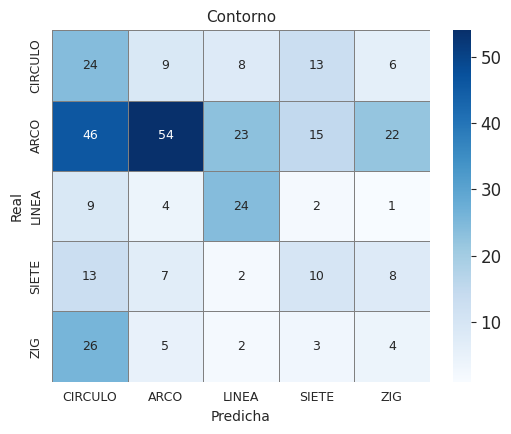

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES_CONTORNO, yticklabels=CLASES_CONTORNO, ax=ax,
            linewidths=0.5, linecolor='gray', annot_kws={'size': 9})
ax.set_xlabel('Predicha', fontsize=10); ax.set_ylabel('Real', fontsize=10)
ax.set_title('Contorno', fontsize=11)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig('resultados/confusion_contorno.png', dpi=150, bbox_inches='tight')
plt.show()


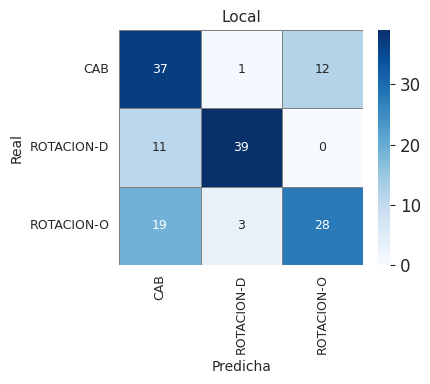

In [19]:
fig, ax = plt.subplots(figsize=(4.5, 4.0))
sns.heatmap(cm_l, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES_LOCAL, yticklabels=CLASES_LOCAL, ax=ax,
            linewidths=0.5, linecolor='gray', annot_kws={'size': 9})
ax.set_xlabel('Predicha', fontsize=10); ax.set_ylabel('Real', fontsize=10)
ax.set_title('Local', fontsize=11)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig('resultados/confusion_local.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.2 Métricas por clase

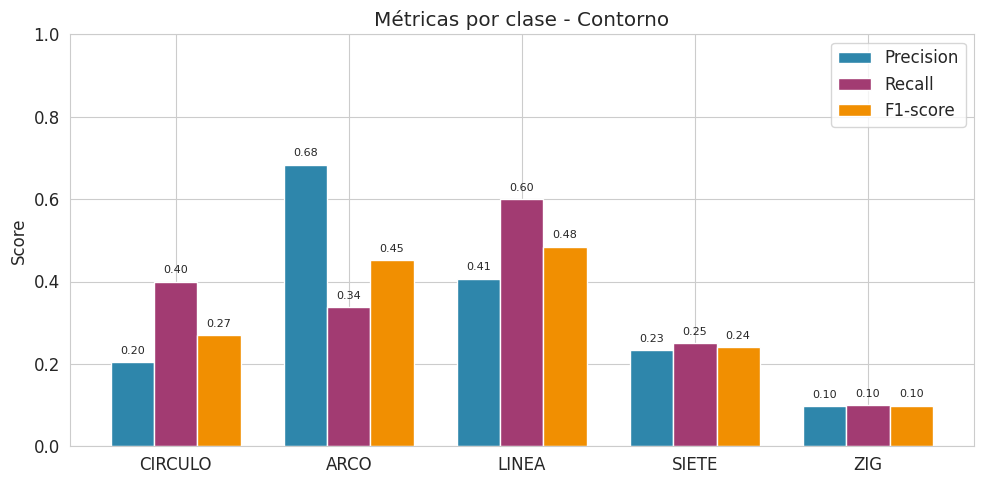

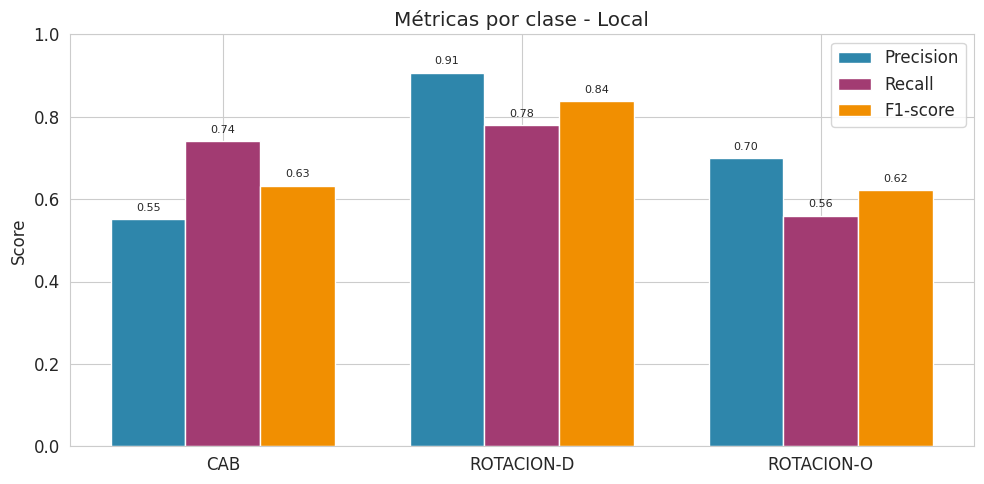

In [20]:
def barras_metricas(yt, yp, clases, nombre):
    prec = [precision_score(yt, yp, labels=[c], average='micro') for c in clases]
    rec  = [recall_score(yt, yp, labels=[c], average='micro') for c in clases]
    f1s  = [f1_score(yt, yp, labels=[c], average='micro') for c in clases]
    x = np.arange(len(clases)); w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, prec, w, label='Precision', color='#2E86AB')
    ax.bar(x,     rec,  w, label='Recall',    color='#A23B72')
    ax.bar(x + w, f1s,  w, label='F1-score',  color='#F18F01')
    ax.set_xticks(x); ax.set_xticklabels(clases)
    ax.set_ylabel('Score'); ax.set_title(f'Métricas por clase - {nombre}')
    ax.set_ylim(0, 1); ax.legend()
    for i in range(len(clases)):
        for j, vals in enumerate([prec, rec, f1s]):
            ax.text(i + (j-1)*w, vals[i] + 0.02, f'{vals[i]:.2f}',
                    ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'resultados/metricas_{nombre.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return pd.DataFrame({'Clase': clases, 'Precision': prec, 'Recall': rec, 'F1': f1s})

df_metrics_c = barras_metricas(yt_c, yp_c, CLASES_CONTORNO, 'Contorno')
df_metrics_l = barras_metricas(yt_l, yp_l, CLASES_LOCAL, 'Local')


## 11. Guardar resultados

In [21]:
acc_c = accuracy_score(yt_c, yp_c)
acc_l = accuracy_score(yt_l, yp_l)

pd.DataFrame({"real": yt_c, "predicho": yp_c}).to_csv(
    "resultados/predicciones_contorno.csv", index=False)
pd.DataFrame({"real": yt_l, "predicho": yp_l}).to_csv(
    "resultados/predicciones_local.csv", index=False)
df_cm_c.to_csv("resultados/confusion_contorno.csv")
df_cm_l.to_csv("resultados/confusion_local.csv")
df_metrics_c.to_csv("resultados/metricas_contorno.csv", index=False)
df_metrics_l.to_csv("resultados/metricas_local.csv", index=False)

resumen = pd.DataFrame({
    "Grupo": ["Contorno", "Local"],
    "Clases": [5, 3],
    "Muestras": [len(yt_c), len(yt_l)],
    "Accuracy": [acc_c, acc_l],
    "Precision (macro)": [
        precision_score(yt_c, yp_c, average="macro"),
        precision_score(yt_l, yp_l, average="macro")],
    "Recall (macro)": [
        recall_score(yt_c, yp_c, average="macro"),
        recall_score(yt_l, yp_l, average="macro")],
    "F1 (macro)": [
        f1_score(yt_c, yp_c, average="macro"),
        f1_score(yt_l, yp_l, average="macro")]
})
resumen.to_csv("resultados/metricas_resumen.csv", index=False)

print("Archivos guardados en resultados/:")
for f in sorted(Path("resultados").iterdir()):
    print(f"  {f.name}")
print(f"\n{resumen.to_string(index=False)}")


Archivos guardados en resultados/:
  confusion_contorno.csv
  confusion_contorno.png
  confusion_local.csv
  confusion_local.png
  dataset_info.csv
  datos_info.csv
  distribucion_antes.png
  distribucion_balance_target.png
  distribucion_clases.png
  distribucion_despues.png
  features_cache.pkl
  features_contorno_stats.csv
  features_local_stats.csv
  features_stats.csv
  hmm_5estados.png
  hmm_arquitectura.png
  hmm_arquitectura_corregida.png
  hmm_selfloop_limpio.png
  hmm_selfloop_perfecto.png
  metricas_contorno.csv
  metricas_contorno.png
  metricas_local.csv
  metricas_local.png
  metricas_resumen.csv
  predicciones_contorno.csv
  predicciones_local.csv

   Grupo  Clases  Muestras  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
Contorno       5       340  0.341176           0.324767        0.337500    0.309225
   Local       3       150  0.693333           0.719739        0.693333    0.697804


## 12. Conclusiones

Más allá de las limitaciones específicas de este trabajo, los HMM han caído en desuso frente a arquitecturas profundas (LSTM, transformers) por varias razones: (i) los HMM asumen que la observación en cada instante depende solo del estado oculto actual, lo cual ignora correlaciones de largo alcance en la señal; (ii) las emisiones Gaussianas con covarianza diagonal no capturan relaciones no lineales entre dimensiones; (iii) el número de estados debe definirse a priori y su interpretación no siempre se corresponde con sub-movimientos reales; y (iv) los HMM son difíciles de escalar a conjuntos grandes de datos y clases. Los modelos modernos, si bien requieren más datos, ofrecen representaciones aprendidas de extremo a extremo y mejor generalización.


**Trabajo futuro:**
- Probar arquitecturas profundas (LSTM, GRU) con los mismos features

## Referencias

- Mitra, S. y Acharya, T. (2007). Gesture Recognition: A Survey. *IEEE Trans. Syst., Man, Cybern. C*, 37(3), 311–324.
- Rabiner, L. R. (1989). A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition. *Proc. IEEE*, 77(2), 257–286.
- Lugaresi, C. et al. (2019). MediaPipe: A Framework for Perceiving and Processing Reality. *Third Workshop on Computer Vision for AR/VR at IEEE CVPR*.
